In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
properties = pd.read_csv('real_estate_properties.csv')
location = pd.read_csv('real_estate_locations.csv')
transaction = pd.read_csv('real_estate_transactions.csv')



In [6]:
print(f"this is the count: {len(properties)} ")


properties.head(5)
location.head()
transaction.head()

this is the count: 350 


,transaction_id,property_id,transaction_date,transaction_price,transaction_type,agent_id
0,1,1,2025-03-29,235696715,Sale,1004
1,2,1,2026-02-22,221610033,Sale,1022
2,3,2,2027-01-12,107543098,Sale,1014
3,4,3,2024-07-11,38865908,Sale,1001
4,5,3,2024-10-29,39385912,Lease,1016


In [7]:
print(location.shape)
print(properties.shape)
print(transaction.shape)

(12, 5)
(350, 10)
(729, 6)


In [8]:
location.isnull().sum()
properties.isnull().sum()
transaction.isnull().sum()

transaction_id       0
property_id          0
transaction_date     0
transaction_price    0
transaction_type     0
agent_id             0
dtype: int64

In [18]:
location.isnull().sum()
transaction.isnull().sum()
properties.isnull().sum()

property_id      0
title            0
property_type    0
bedrooms         0
bathrooms        0
size_sqm         0
location_id      0
listing_price    0
status           0
listed_date      0
dtype: int64

In [11]:
location_clean = location.copy()
properties_clean = properties.copy()
transaction_clean = transaction.copy()

In [12]:
properties_clean.head(5)

,property_id,title,property_type,bedrooms,bathrooms,size_sqm,location_id,listing_price,status,listed_date
0,1,Land in Woji,Land,0,0,325,7,218213575,Available,2024-05-16
1,2,Flat in D-Line,Flat,1,1,146,10,110464622,Available,2026-01-21
2,3,Commercial in Diobu,Commercial,0,1,115,9,36098116,Rented,2024-04-21
3,4,Land in Rumuokoro,Land,0,0,874,4,373406424,Sold,2026-01-21
4,5,Flat in Diobu,Flat,4,3,135,9,46734755,Available,2023-01-14


In [13]:
properties_clean['Listed_date'] = pd.to_datetime(
    properties_clean['listed_date']
)
properties_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   property_id    350 non-null    int64         
 1   title          350 non-null    object        
 2   property_type  350 non-null    object        
 3   bedrooms       350 non-null    int64         
 4   bathrooms      350 non-null    int64         
 5   size_sqm       350 non-null    int64         
 6   location_id    350 non-null    int64         
 7   listing_price  350 non-null    int64         
 8   status         350 non-null    object        
 9   listed_date    350 non-null    object        
 10  Listed_date    350 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(6), object(4)
memory usage: 30.2+ KB


In [15]:
print(transaction_clean)

     transaction_id  property_id transaction_date  transaction_price  \
0                 1            1       2025-03-29          235696715   
1                 2            1       2026-02-22          221610033   
2                 3            2       2027-01-12          107543098   
3                 4            3       2024-07-11           38865908   
4                 5            3       2024-10-29           39385912   
..              ...          ...              ...                ...   
724             725          347       2024-12-11          321960169   
725             726          348       2025-06-23          468134662   
726             727          349       2024-03-03          118683731   
727             728          349       2024-12-22          149726453   
728             729          350       2024-11-30          288152721   

    transaction_type  agent_id  
0               Sale      1004  
1               Sale      1022  
2               Sale      1014  
3  

In [16]:
transaction_clean['transaction_date'] = pd.to_datetime(
    transaction_clean['transaction_date']
)

In [17]:
properties_clean.info()
#transaction_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   property_id    350 non-null    int64         
 1   title          350 non-null    object        
 2   property_type  350 non-null    object        
 3   bedrooms       350 non-null    int64         
 4   bathrooms      350 non-null    int64         
 5   size_sqm       350 non-null    int64         
 6   location_id    350 non-null    int64         
 7   listing_price  350 non-null    int64         
 8   status         350 non-null    object        
 9   listed_date    350 non-null    object        
 10  Listed_date    350 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(6), object(4)
memory usage: 30.2+ KB


In [39]:
properties_clean = properties_clean.drop_duplicates()
transaction_clean = transaction_clean.drop_duplicates()


In [18]:
properties_location = properties_clean.merge(
    location_clean, on='location_id', how= 'left'
)
properties_location.head()

,property_id,title,property_type,bedrooms,bathrooms,size_sqm,location_id,listing_price,status,listed_date,Listed_date,neighborhood,city,state,avg_price_per_sqm
0,1,Land in Woji,Land,0,0,325,7,218213575,Available,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000
1,2,Flat in D-Line,Flat,1,1,146,10,110464622,Available,2026-01-21,2026-01-21,D-Line,Port Harcourt,Rivers,620000
2,3,Commercial in Diobu,Commercial,0,1,115,9,36098116,Rented,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000
3,4,Land in Rumuokoro,Land,0,0,874,4,373406424,Sold,2026-01-21,2026-01-21,Rumuokoro,Obio-Akpor,Rivers,450000
4,5,Flat in Diobu,Flat,4,3,135,9,46734755,Available,2023-01-14,2023-01-14,Diobu,Port Harcourt,Rivers,350000


In [20]:
real_estate_data = transaction_clean .merge(
     properties_location, on='property_id', how='left'
)

real_estate_data.head(5)

,transaction_id,property_id,transaction_date,transaction_price,transaction_type,agent_id,title,property_type,bedrooms,bathrooms,size_sqm,location_id,listing_price,status,listed_date,Listed_date,neighborhood,city,state,avg_price_per_sqm
0,1,1,2025-03-29,235696715,Sale,1004,Land in Woji,Land,0,0,325,7,218213575,Available,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000
1,2,1,2026-02-22,221610033,Sale,1022,Land in Woji,Land,0,0,325,7,218213575,Available,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000
2,3,2,2027-01-12,107543098,Sale,1014,Flat in D-Line,Flat,1,1,146,10,110464622,Available,2026-01-21,2026-01-21,D-Line,Port Harcourt,Rivers,620000
3,4,3,2024-07-11,38865908,Sale,1001,Commercial in Diobu,Commercial,0,1,115,9,36098116,Rented,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000
4,5,3,2024-10-29,39385912,Lease,1016,Commercial in Diobu,Commercial,0,1,115,9,36098116,Rented,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000


In [21]:
real_estate_data['price_per_sqm'] = (real_estate_data['transaction_price']/real_estate_data['size_sqm'])

In [22]:
real_estate_data['transaction_year'] = (real_estate_data['transaction_date'].dt.year

)

In [23]:
real_estate_data['transaction_of_month'] = (real_estate_data['transaction_date'].dt.month_name()
)

In [24]:
real_estate_data['price_hold'] = (
    real_estate_data['listing_price']- real_estate_data['transaction_price']

)



In [25]:
real_estate_data.head()
#real_estate_data.info()
#real_estate_data.describe()

,transaction_id,property_id,transaction_date,transaction_price,transaction_type,agent_id,title,property_type,bedrooms,bathrooms,...,listed_date,Listed_date,neighborhood,city,state,avg_price_per_sqm,price_per_sqm,transaction_year,transaction_of_month,price_hold
0,1,1,2025-03-29,235696715,Sale,1004,Land in Woji,Land,0,0,...,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000,725220.661538,2025,March,-17483140
1,2,1,2026-02-22,221610033,Sale,1022,Land in Woji,Land,0,0,...,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000,681877.024615,2026,February,-3396458
2,3,2,2027-01-12,107543098,Sale,1014,Flat in D-Line,Flat,1,1,...,2026-01-21,2026-01-21,D-Line,Port Harcourt,Rivers,620000,736596.561644,2027,January,2921524
3,4,3,2024-07-11,38865908,Sale,1001,Commercial in Diobu,Commercial,0,1,...,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000,337964.417391,2024,July,-2767792
4,5,3,2024-10-29,39385912,Lease,1016,Commercial in Diobu,Commercial,0,1,...,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000,342486.191304,2024,October,-3287796


In [27]:
avg_transaction_location = (
    real_estate_data.groupby('neighborhood') 
    ['transaction_price']
    .mean()
   # .sort_vaules(ascending=False)
    #.reset_index()
)

type(avg_transaction_location)

pandas.core.series.Series

In [28]:
avg_transaction_location = avg_transaction_location.sort_values(ascending=False)
avg_transaction_location

neighborhood
GRA Phase 2    4.551535e+08
GRA Phase 1    4.488501e+08
Old GRA        3.206371e+08
Woji           2.956618e+08
D-Line         2.598889e+08
Town           2.480773e+08
Ada George     2.366855e+08
Rumuokoro      2.157178e+08
Rumuodara      2.089597e+08
Rumuola        1.837568e+08
Diobu          1.471010e+08
Borokiri       1.224452e+08
Name: transaction_price, dtype: float64

In [29]:
avg_transaction_location = (avg_transaction_location)
avg_transaction_location.head()
#type(avg_transaction_location)

neighborhood
GRA Phase 2    4.551535e+08
GRA Phase 1    4.488501e+08
Old GRA        3.206371e+08
Woji           2.956618e+08
D-Line         2.598889e+08
Name: transaction_price, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

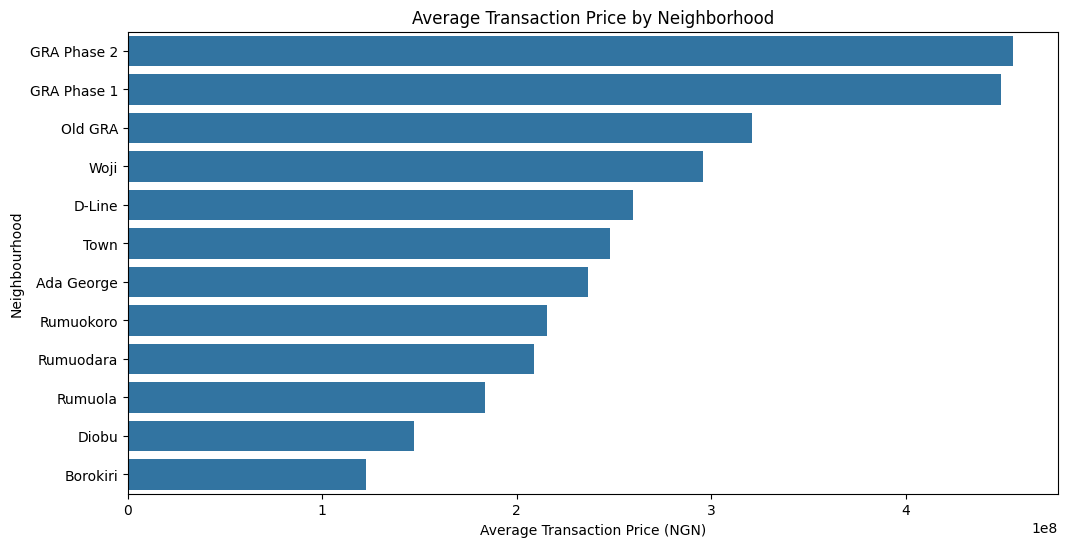

In [96]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_transaction_location, x= 'transaction_price',
    y='neighborhood'
)

plt.title('Average Transaction Price by Neighborhood')
plt.xlabel('Average Transaction Price (NGN)')
plt.ylabel('Neighbourhood')
plt.show

In [30]:
real_estate_data.head()

,transaction_id,property_id,transaction_date,transaction_price,transaction_type,agent_id,title,property_type,bedrooms,bathrooms,...,listed_date,Listed_date,neighborhood,city,state,avg_price_per_sqm,price_per_sqm,transaction_year,transaction_of_month,price_hold
0,1,1,2025-03-29,235696715,Sale,1004,Land in Woji,Land,0,0,...,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000,725220.661538,2025,March,-17483140
1,2,1,2026-02-22,221610033,Sale,1022,Land in Woji,Land,0,0,...,2024-05-16,2024-05-16,Woji,Obio-Akpor,Rivers,550000,681877.024615,2026,February,-3396458
2,3,2,2027-01-12,107543098,Sale,1014,Flat in D-Line,Flat,1,1,...,2026-01-21,2026-01-21,D-Line,Port Harcourt,Rivers,620000,736596.561644,2027,January,2921524
3,4,3,2024-07-11,38865908,Sale,1001,Commercial in Diobu,Commercial,0,1,...,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000,337964.417391,2024,July,-2767792
4,5,3,2024-10-29,39385912,Lease,1016,Commercial in Diobu,Commercial,0,1,...,2024-04-21,2024-04-21,Diobu,Port Harcourt,Rivers,350000,342486.191304,2024,October,-3287796


In [31]:
avg_sqm_price = (
    real_estate_data.groupby('neighborhood')
    ['price_per_sqm'].mean()
)
type(avg_sqm_price)

pandas.core.series.Series

In [32]:
type(avg_sqm_price)

pandas.core.series.Series

In [33]:
avg_sqm_price = (avg_sqm_price.sort_values(ascending=False))
avg_sqm_price

neighborhood
GRA Phase 2    1.154104e+06
GRA Phase 1    9.260907e+05
Old GRA        9.069112e+05
D-Line         6.964688e+05
Town           6.797656e+05
Woji           6.665983e+05
Rumuola        6.058816e+05
Ada George     5.489793e+05
Rumuokoro      5.197830e+05
Rumuodara      4.850620e+05
Diobu          4.074150e+05
Borokiri       3.504813e+05
Name: price_per_sqm, dtype: float64

In [34]:
avg_sqm_price = (avg_sqm_price.reset_index())
avg_sqm_price

,neighborhood,price_per_sqm
0,GRA Phase 2,1.154104e+06
1,GRA Phase 1,9.260907e+05
2,Old GRA,9.069112e+05
3,D-Line,6.964688e+05
4,Town,6.797656e+05
5,Woji,6.665983e+05
6,Rumuola,6.058816e+05
7,Ada George,5.489793e+05
8,Rumuokoro,5.197830e+05
9,Rumuodara,4.850620e+05


In [35]:
type(avg_sqm_price)

pandas.core.frame.DataFrame

In [36]:
avg_sqm_price.head(3)

,neighborhood,price_per_sqm
0,GRA Phase 2,1.154104e+06
1,GRA Phase 1,9.260907e+05
2,Old GRA,9.069112e+05


<function matplotlib.pyplot.show(close=None, block=None)>

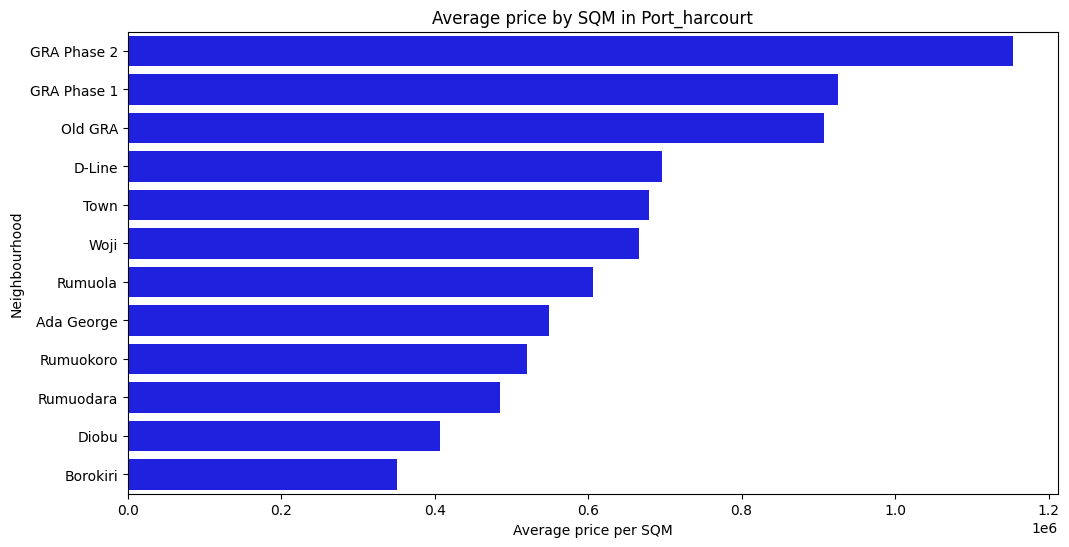

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_sqm_price, x= 'price_per_sqm',
    y='neighborhood', color='blue'
)

plt.title('Average price by SQM in Port_harcourt',)
plt.xlabel('Average price per SQM')
plt.ylabel('Neighbourhood')
plt.show

In [44]:
property_distribution = (
    real_estate_data['property_type'].value_counts().reset_index()
)
property_distribution.columns = ['property_type', 'transaction_count']
property_distribution

,property_type,transaction_count
0,Commercial,200
1,Duplex,193
2,Land,192
3,Flat,144


<function matplotlib.pyplot.show(close=None, block=None)>

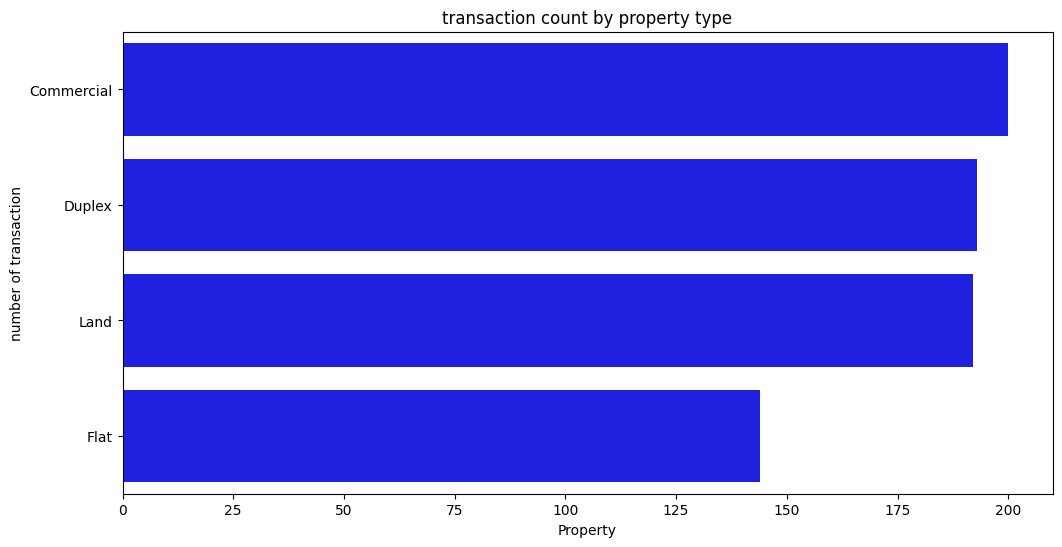

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=property_distribution, x= 'transaction_count',
    y='property_type', color='blue'
)

plt.title('transaction count by property type')
plt.xlabel('Property')
plt.ylabel('number of transaction')
plt.show

In [47]:
property_value = (
    real_estate_data.groupby('property_type') 
    ['transaction_price'].mean().sort_values(ascending=False).reset_index()
)
property_value

,property_type,transaction_price
0,Land,5.428373e+08
1,Commercial,2.138010e+08
2,Duplex,1.966509e+08
3,Flat,7.883172e+07


<function matplotlib.pyplot.show(close=None, block=None)>

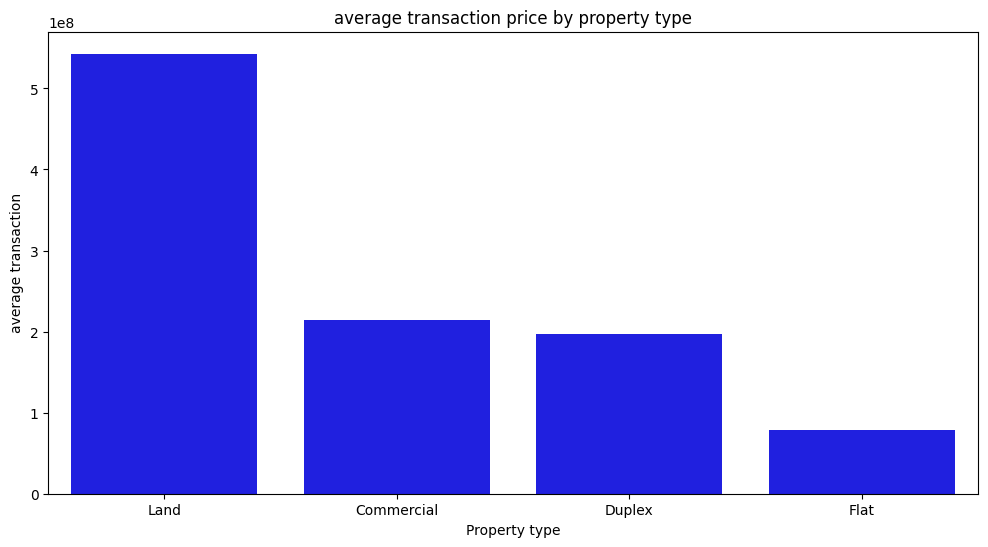

In [49]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=property_value, x= 'property_type',
    y='transaction_price', color='blue'
)

plt.title('average transaction price by property type')
plt.xlabel('Property type')
plt.ylabel('average transaction')
plt.show

In [52]:
real_estate_data['property_type'] = (real_estate_data['property_type'].replace({
    'Commerical': 'Commercial', 
    'Land' : 'Land', 'Flat': 'Residential', 'Duplex': "Residential"
    })
)
real_estate_data['property_type'].value_counts()

property_type
Residential    337
Commercial     200
Land           192
Name: count, dtype: int64

In [56]:
pd.options.display.float_format = '{:,.0f}'.format

In [57]:
prop_value = (real_estate_data.groupby('property_type')
              ['transaction_price'].mean().sort_values().reset_index()
    )
prop_value


,property_type,transaction_price
0,Residential,"146,306,795"
1,Commercial,"213,800,965"
2,Land,"542,837,320"


<function matplotlib.pyplot.show(close=None, block=None)>

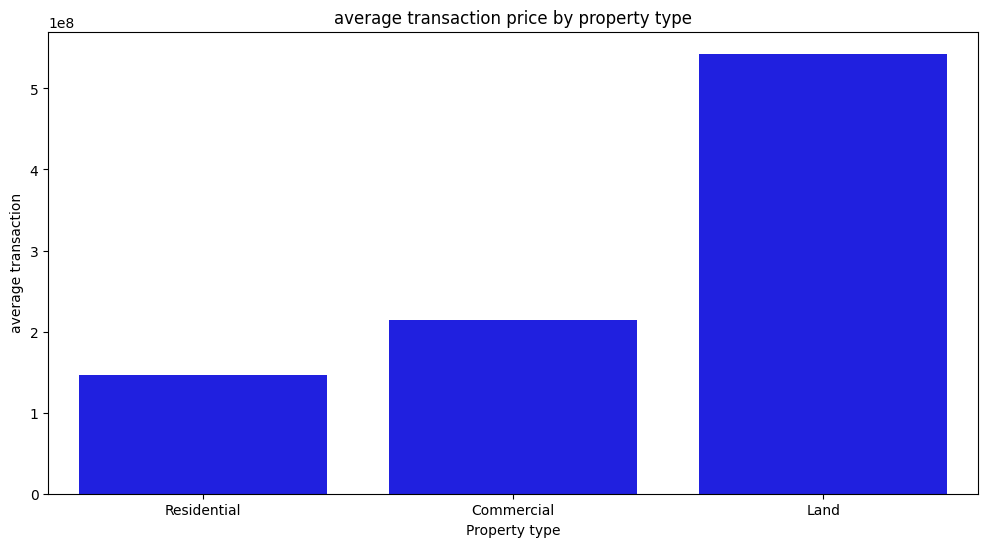

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=prop_value, x= 'property_type',
    y='transaction_price', color='blue'
)

plt.title('average transaction price by property type')
plt.xlabel('Property type')
plt.ylabel('average transaction')
plt.show

In [60]:
real_estate_data.to_csv('real_estate_analysis.csv', index= False)